
## Context
This is the dataset used in the second chapter of Aurélien Géron's recent book 'Hands-On Machine learning with Scikit-Learn and TensorFlow'. It serves as an excellent introduction to implementing machine learning algorithms because it requires rudimentary data cleaning, has an easily understandable list of variables and sits at an optimal size between being to toyish and too cumbersome.

The data contains information from the 1990 California census. So although it may not help you with predicting current housing prices like the Zillow Zestimate dataset, it does provide an accessible introductory dataset for teaching people about the basics of machine learning.

## Content
The data pertains to the houses found in a given California district and some summary stats about them based on the 1990 census data. Be warned the data aren't cleaned so there are some preprocessing steps required! The columns are as follows, their names are pretty self explanitory:


About this file

Add Suggestion
1. longitude: A measure of how far west a house is; a higher value is farther west
2. latitude: A measure of how far north a house is; a higher value is farther north
3. housing_median_age: Median age of a house within a block; a lower number is a newer building
4. total_rooms: Total number of rooms within a block
5. total_bedrooms: Total number of bedrooms within a block
6. population: Total number of people residing within a block
7. households: Total number of households, a group of people residing within a home unit, for a block
8. median_income: Median income for households within a block of houses (measured in tens of thousands of US Dollars)
9. median_house_value: Median house value for households within a block (measured in US Dollars)
10. ocean_proximity: Location of the house w.r.t ocean/sea

In [3]:
import pandas as pd
import matplotlib.pyplot as plt


In [5]:
!ls

Clase1_introduccion_sin_resolver-Copy1.ipynb
Clase1_introduccion_sin_resolver.ipynb
housing.csv


In [4]:
df = pd.read_csv('housing.csv')

In [6]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


## Motivación: Quiero vender mi casa, ¿en cuanto la vendo? 



## Ubicación

Text(0.5, 1.0, 'Distribución de precios según Longitud y Latitud')

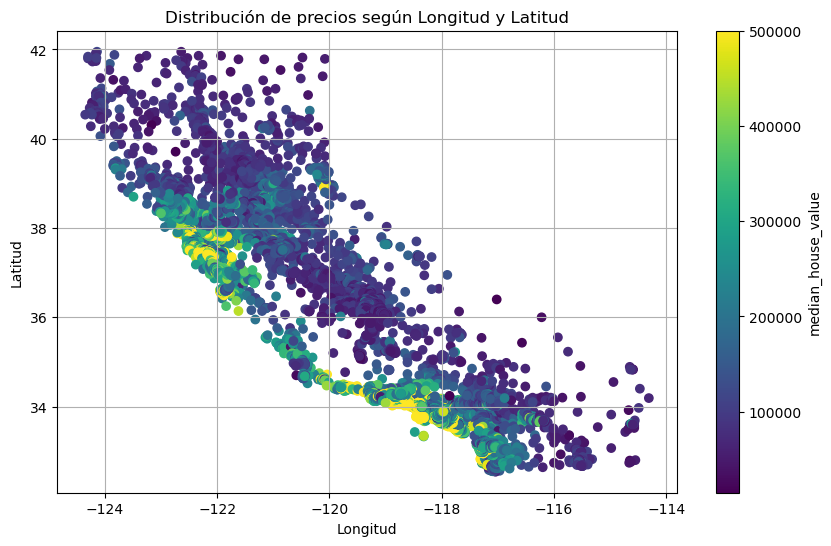

In [7]:
plt.figure(figsize=(10, 6))

# Primer scatter para los puntos de color según el valor de 'median_house_value'
scatter = plt.scatter(df['longitude'], df['latitude'], c=df['median_house_value'])

# Agregar una barra de color que representa 'median_house_value'
plt.colorbar(scatter, label='median_house_value')

# Agregar una cuadrícula
plt.grid(True)

# Etiquetas y título
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.title('Distribución de precios según Longitud y Latitud')

#### Primer insight (no tan sorprendente) las casas más caras están cerca de la playa

## Edad de la casa

In [10]:
df.housing_median_age.mean()

28.639486434108527

In [11]:
df.housing_median_age.describe()

count    20640.000000
mean        28.639486
std         12.585558
min          1.000000
25%         18.000000
50%         29.000000
75%         37.000000
max         52.000000
Name: housing_median_age, dtype: float64

<Axes: >

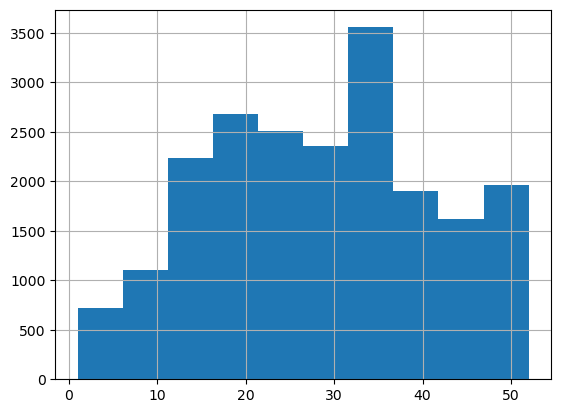

In [12]:
df.housing_median_age.hist()

Casas nuevas y michas casas viejas 

## Cuartos 

In [13]:
df.total_rooms.describe()

count    20640.000000
mean      2635.763081
std       2181.615252
min          2.000000
25%       1447.750000
50%       2127.000000
75%       3148.000000
max      39320.000000
Name: total_rooms, dtype: float64

Cuartos promedio por casa en cada bloque 

<Axes: >

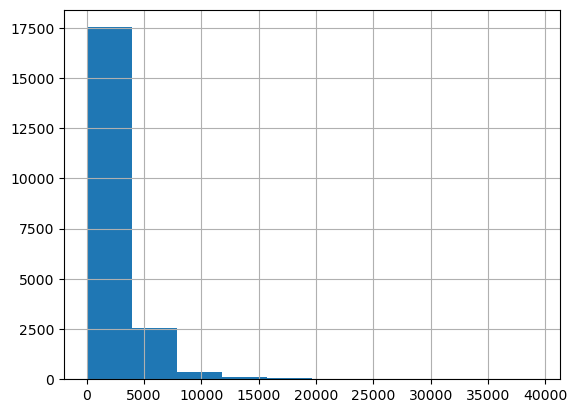

In [14]:
df.total_rooms.hist()

## Population

In [18]:
df.population.describe()

count    20640.000000
mean      1425.476744
std       1132.462122
min          3.000000
25%        787.000000
50%       1166.000000
75%       1725.000000
max      35682.000000
Name: population, dtype: float64

## Households

In [20]:
df['rooms_per_houshold'] = df.total_rooms / df.households

## Ingreso del hogar

<Axes: >

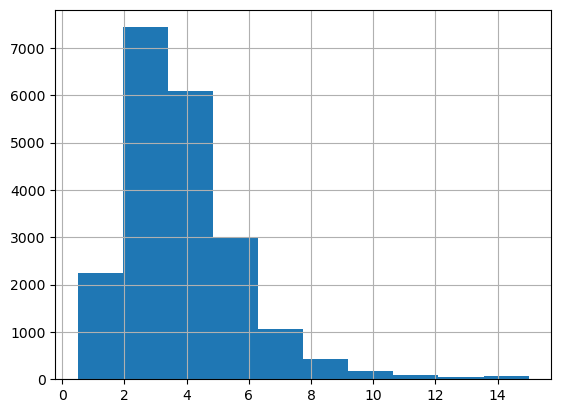

In [22]:
df.median_income.hist()

## Cercania con el oceano 

In [25]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_houshold
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853
...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,5.045455
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,6.114035
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,5.205543
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,5.329513


In [27]:
df.groupby('ocean_proximity').mean()['median_house_value']

ocean_proximity
<1H OCEAN     240084.285464
INLAND        124805.392001
ISLAND        380440.000000
NEAR BAY      259212.311790
NEAR OCEAN    249433.977427
Name: median_house_value, dtype: float64

### Supongamos que mi ingreso mensual es de $3,400 dolares, ¿en cuanto podría vender mi casa aproximadamente?

Podría sacar el promedio de las casas que valen $3,400 

In [30]:
df.query("median_income == 3.4").median_house_value.median()

198750.0

In [31]:
df.query("median_income == 3.4").median_house_value.mean()

188133.33333333334

In [35]:
df.query("median_income == 3.4")

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_houshold
3431,-118.44,34.27,35.0,777.0,187.0,1022.0,186.0,3.4,139600.0,<1H OCEAN,4.177419
3459,-118.44,34.30,38.0,1595.0,314.0,1181.0,327.0,3.4,155500.0,<1H OCEAN,4.877676
5851,-118.32,34.18,44.0,1594.0,389.0,832.0,340.0,3.4,212100.0,<1H OCEAN,4.688235
8492,-118.30,33.90,27.0,3267.0,762.0,2099.0,647.0,3.4,224100.0,<1H OCEAN,5.049459
11183,-117.94,33.82,27.0,1366.0,326.0,878.0,325.0,3.4,196900.0,<1H OCEAN,4.203077
14630,-117.18,32.77,23.0,1215.0,225.0,592.0,224.0,3.4,200600.0,NEAR OCEAN,5.424107


In [36]:
df.query("median_income > 3 & median_income < 3.5").median_house_value.mean()

180917.4464684015

Supongamos que mi ingreso mensual es de $9,000 dolares, ¿en cuanto podría vender mi casa aproximadamente?

In [49]:
df.query("median_income > 8.6 & median_income < 9.2").median_house_value.mean()

445028.9117647059

No hay datos, pero intuitivamente uno pude pensar que si el ingreso mensual de una familia es de 9,000 dolares la casa vale más que uno de 8,000 pero menos que una de 10,000.

Es decir, a mayor ingreso familiar, mayor precio de la cas ...¿pero que tanto sube?

Text(0, 0.5, 'Precio')

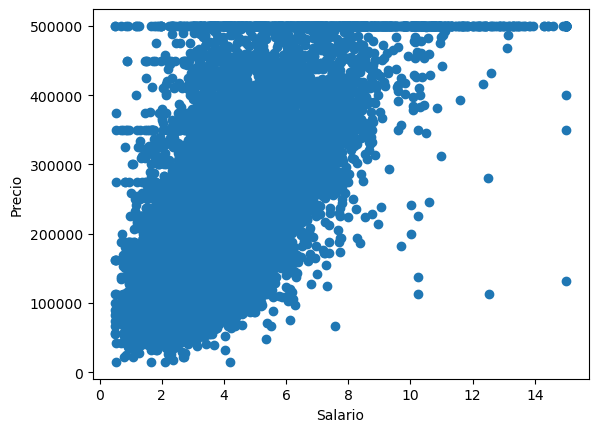

In [51]:
plt.scatter(df.median_income, df.median_house_value)
plt.xlabel("Salario")
plt.ylabel("Precio")

In [53]:
import numpy as np

Problema1: se puso un tope de 500K dolares a las casas más caras 

In [57]:
np.mean(df.median_house_value == 500001) 

0.04675387596899225

En total, 4.6% de las casas tienen el mismo precio topado, vamos a eliminar estos casos

In [58]:
df_not_all = df[df.median_house_value == 500001]

Con esta vista, no hay datos disponibles para poder estimar cunato cuesta una casa en un ingreso familiar premium, pero claramente serían más caras

La idea es venderle casas a millonarios, pero no tengo datos de esa clase de hogares. ¿Cómo le podemos hacer?

### Percentiles 

Percentiles del valor mediano de las casas, crea 5 bines

In [76]:
df['median_income_bin5'] = pd.qcut(df['median_income'], q=10, labels=False) + 1

In [77]:
#pd.qcut(df['median_income'], q=5, labels=False) + 1

In [79]:
#del df['ocean_proximity']

In [80]:
df.groupby('median_income_bin5').mean()[['median_income', 'median_house_value']]

,median_income,median_house_value
median_income_bin5,,
1,1.515145,110179.676186
2,2.139838,126633.772287
3,2.557075,147723.127000
4,2.955537,166314.465667
5,3.326199,186252.415736
6,3.732804,201508.156977
7,4.182009,220746.880929
8,4.763660,239329.370999
9,5.577262,279994.330426


10 bins

In [81]:
grouped_median_income = df.groupby('median_income_bin5').mean()

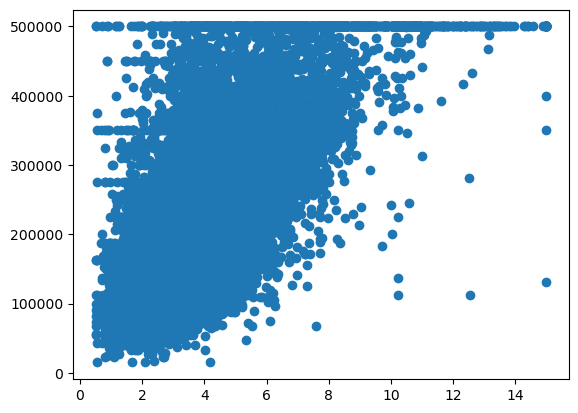

In [82]:
plt.scatter(df.median_income, df.median_house_value)

Text(0.5, 1.0, 'Bivariado salario vs precio')

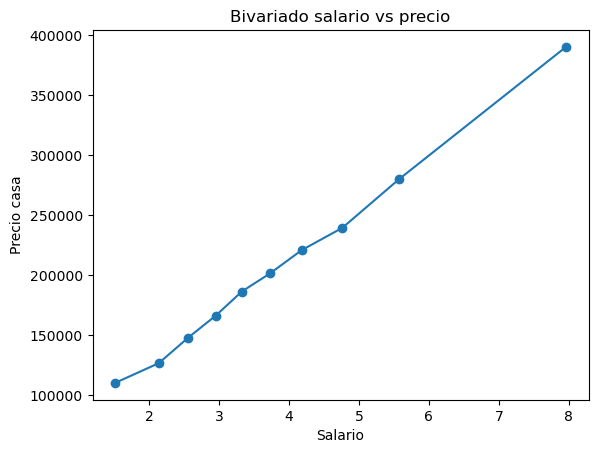

In [83]:
plt.plot(grouped_median_income.median_income, grouped_median_income.median_house_value, marker="o")
plt.xlabel("Salario")
plt.ylabel("Precio casa")
plt.title("Bivariado salario vs precio")

<Axes: >

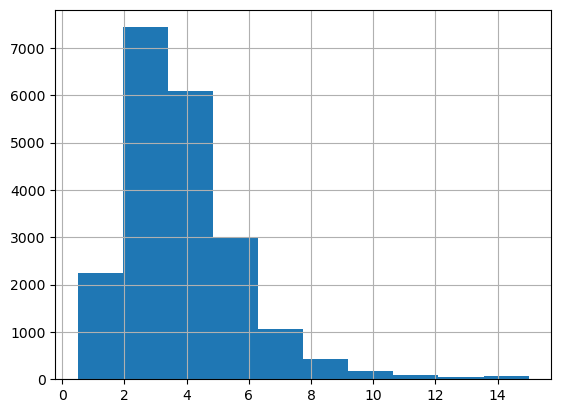

In [73]:
df.median_income.hist()

<Axes: >

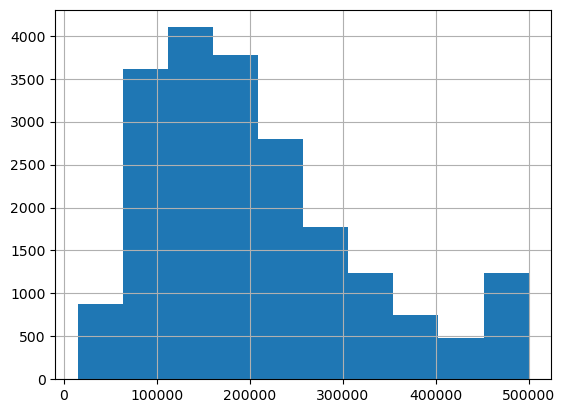

In [74]:
df.median_house_value.hist()

### Analisis bivariado 

median house age

In [86]:
df['median_age_bin5'] = pd.qcut(df['housing_median_age'], q=10, labels=False) + 1

In [87]:
grouped_median_age = df.groupby('median_age_bin5').mean()

Text(0.5, 1.0, 'Bivariado edad vs precio')

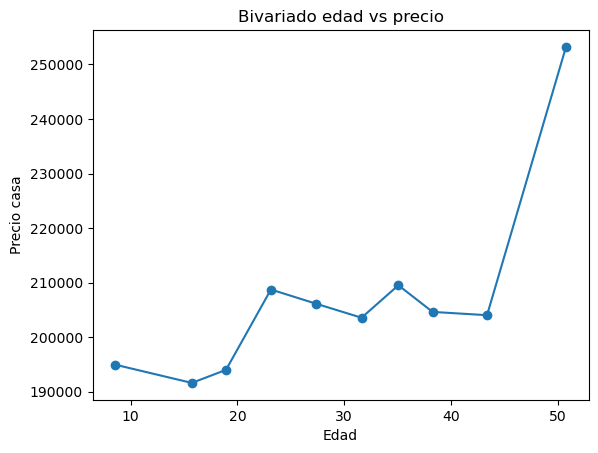

In [88]:
plt.plot(grouped_median_age.housing_median_age, grouped_median_age.median_house_value, marker="o")
plt.xlabel("Edad")
plt.ylabel("Precio casa")
plt.title("Bivariado edad vs precio")

## Analisis bivariado del total de cuartos

### Bivariado median_house_value